# Task 4: Proxy Target Variable Engineering

## Objective

The dataset does not contain a true loan default label.

To enable supervised learning, an RFM-based proxy target variable will be created.

Customers will be segmented according to:

- Recency
- Frequency
- Monetary Value

K-Means clustering will then identify customer groups.

The least engaged customer segment will be labeled as high-risk.

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("../data/raw/data.csv")
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [2]:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

In [3]:
snapshot_date = (
    df["TransactionStartTime"].max()
    + pd.Timedelta(days=1)
)

snapshot_date

Timestamp('2019-02-14 10:01:28+0000', tz='UTC')

In [4]:
rfm = (
    df.groupby("CustomerId")
    .agg(
        Recency=(
            "TransactionStartTime",
            lambda x: (
                snapshot_date - x.max()
            ).days
        ),
        Frequency=(
            "TransactionId",
            "count"
        ),
        Monetary=(
            "Amount",
            "sum"
        )
    )
    .reset_index()
)

rfm.head()

,CustomerId,Recency,Frequency,Monetary
0,CustomerId_1,84,1,-10000.0
1,CustomerId_10,84,1,-10000.0
2,CustomerId_1001,90,5,20000.0
3,CustomerId_1002,26,11,4225.0
4,CustomerId_1003,12,6,20000.0


In [5]:
rfm_features = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_features
)

In [6]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm["cluster"] = kmeans.fit_predict(
    rfm_scaled
)

In [7]:
rfm.groupby("cluster")[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
].mean()

,Recency,Frequency,Monetary
cluster,,,
0,61.877279,7.720196,8.172068e+04
1,12.726566,34.800000,2.725741e+05
2,29.000000,4091.000000,-1.049000e+08


In [8]:
rfm["is_high_risk"] = (
    rfm["cluster"] == 0
).astype(int)

rfm.head()

,CustomerId,Recency,Frequency,Monetary,cluster,is_high_risk
0,CustomerId_1,84,1,-10000.0,0,1
1,CustomerId_10,84,1,-10000.0,0,1
2,CustomerId_1001,90,5,20000.0,0,1
3,CustomerId_1002,26,11,4225.0,1,0
4,CustomerId_1003,12,6,20000.0,1,0


In [9]:
rfm["is_high_risk"].value_counts()

is_high_risk
0    2316
1    1426
Name: count, dtype: int64

In [10]:
df_with_target = df.merge(
    rfm[["CustomerId", "is_high_risk"]],
    on="CustomerId",
    how="left"
)

df_with_target.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult,is_high_risk
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0,1
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0,0


In [11]:
df_with_target.shape

(95662, 17)

In [12]:
df_with_target["is_high_risk"].value_counts()

is_high_risk
0    84653
1    11009
Name: count, dtype: int64

In [13]:
df_with_target.to_csv(
    "../data/processed/processed_data.csv",
    index=False
)

### task 4 summary  
   Target Distribution:

- Low Risk (0): 2316 customers
- High Risk (1): 1426 customers

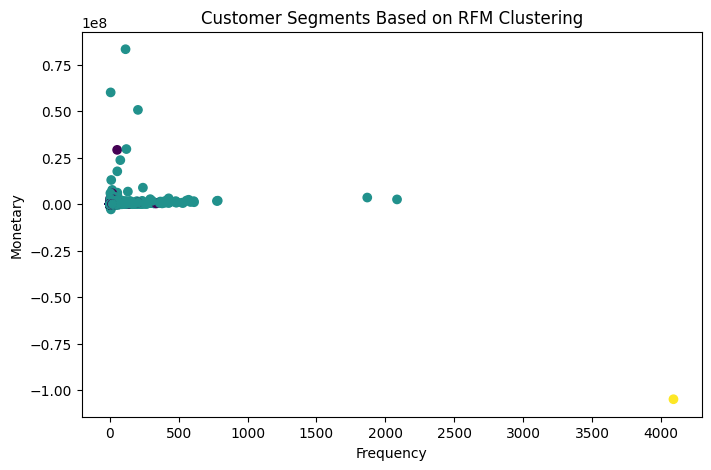

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["cluster"]
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments Based on RFM Clustering")

plt.show()

In [16]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/processed_data.csv"
)

print(df.columns)

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult',
       'is_high_risk'],
      dtype='str')
